In [46]:
import cfad
import pandas as pd


In [47]:
mouse = 2
channel_coords = rf"Z:\Saij\ccf_channels\Mouse {mouse}.csv"

In [48]:
df = pd.read_csv(channel_coords)

In [49]:
df

,channel_id,rel_x,rel_y,ccf_ap,ccf_dv,ccf_ml,region_id,acronym
0,0,0.0,1440.0,9503.918359,2937.969332,4999.287571,795,PAG
1,1,32.0,1440.0,9503.918359,2938.864087,5031.275060,795,PAG
2,2,0.0,1455.0,9501.638372,2923.149419,4999.702114,795,PAG
3,3,32.0,1455.0,9501.638372,2924.044174,5031.689603,795,PAG
4,4,0.0,1470.0,9499.358386,2908.329506,5000.116657,795,PAG
...,...,...,...,...,...,...,...,...
379,379,32.0,3555.0,9182.440250,849.256383,5089.725625,434,RSPd2/3
380,380,0.0,3570.0,9180.160264,833.541715,5058.152679,434,RSPd2/3
381,381,32.0,3570.0,9180.160264,834.436470,5090.140168,434,RSPd2/3
382,382,0.0,3585.0,9177.880277,818.721802,5058.567222,434,RSPd2/3


In [50]:
region_boundaries = df.groupby(['region_id', 'acronym'])['rel_y'].agg(
    min_rel_y='min',
    max_rel_y='max'
).reset_index()


In [51]:
region_boundaries

,region_id,acronym,min_rel_y,max_rel_y
0,0,Void,3315.0,3375.0
1,10,SCig,2625.0,2835.0
2,17,SCiw,2265.0,2610.0
3,26,SCdg,2040.0,2280.0
4,42,SCdw,1920.0,2055.0
5,434,RSPd2/3,3480.0,3585.0
6,442,RSPd1,3435.0,3525.0
7,542,RSPv1,3360.0,3450.0
8,795,PAG,720.0,1920.0
9,834,SCzo,3255.0,3300.0


In [52]:
sorted_boundaries = region_boundaries.sort_values(by='min_rel_y', ascending=False)


In [53]:
sorted_boundaries = sorted_boundaries.reset_index(drop = True)
sorted_boundaries

,region_id,acronym,min_rel_y,max_rel_y
0,434,RSPd2/3,3480.0,3585.0
1,442,RSPd1,3435.0,3525.0
2,542,RSPv1,3360.0,3450.0
3,0,Void,3315.0,3375.0
4,834,SCzo,3255.0,3300.0
5,842,SCsg,2955.0,3270.0
6,851,SCop,2850.0,2970.0
7,10,SCig,2625.0,2835.0
8,17,SCiw,2265.0,2610.0
9,26,SCdg,2040.0,2280.0


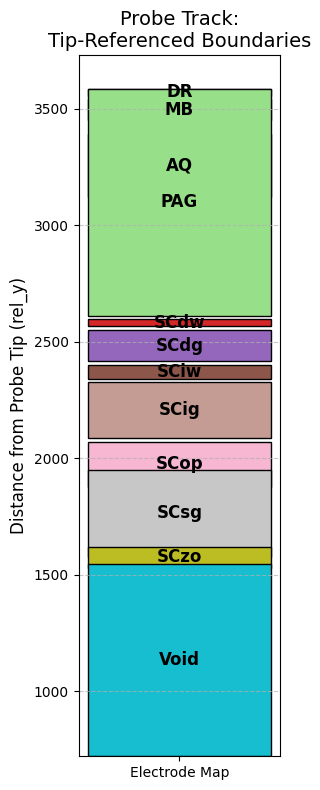

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'sorted_boundaries' is your working DataFrame, sorted exactly as before

# 1. Prepare dimensions exactly as we did in the working version
num_regions = len(sorted_boundaries)
heights = sorted_boundaries['max_rel_y'] - sorted_boundaries['min_rel_y']
bottoms = sorted_boundaries['min_rel_y']

# 2. Automatic color assignment
cmap = plt.get_cmap('tab20')
colors = [cmap(i / num_regions) for i in range(num_regions)]

# 3. Create figure and axis
fig, ax = plt.subplots(figsize=(3, 8))

# 4. Create the stacked bar using your original, working logic
for i in range(num_regions):
    ax.bar(
        x=0, 
        height=heights[i], 
        bottom=bottoms[i], 
        color=colors[i], 
        edgecolor='black',
        width=0.5
    )
    
    # 5. Add text labels directly inside the colored blocks
    mid_point = bottoms[i] + (heights[i] / 2)
    ax.text(
        x=0, 
        y=mid_point, 
        s=sorted_boundaries['acronym'].iloc[i], 
        ha='center', 
        va='center', 
        color='black',
        fontweight='bold',
        fontsize=12
    )

# 6. Customize the axes
ax.set_ylabel('Distance from Probe Tip (rel_y)', fontsize=12)
ax.set_title('Probe Track:\nTip-Referenced Boundaries', fontsize=14)
ax.set_xticks([0])
ax.set_xticklabels(['Electrode Map'])

# CRITICAL FIX: We simply do NOT call ax.invert_yaxis() here.
# Standard Cartesian plotting places the lowest numerical value (0) at the bottom.

# 7. Add a horizontal grid for depth estimation
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Save the plot securely
plt.tight_layout()


In [10]:
sorted_boundaries

,region_id,acronym,min_rel_y,max_rel_y
0,0,Void,3180.0,3585.0
1,834,SCzo,3105.0,3195.0
2,842,SCsg,2775.0,3135.0
3,851,SCop,2625.0,2835.0
4,10,SCig,2400.0,2625.0
5,17,SCiw,2310.0,2385.0
6,26,SCdg,2160.0,2310.0
7,42,SCdw,2115.0,2145.0
8,140,AQ,1335.0,1590.0
9,313,MB,1185.0,1260.0


In [11]:
probe_path = r"Z:\Saij\Herbs probes\Mouse 2\probe_ccf_vox.npy"

In [12]:
probe = np.load(probe_path) * 25

In [14]:
print(probe)

[[9225 1125 5050]
 [9775 4700 4950]]
